In [6]:
# ===============================
# Hercules tutorial notebook
# ===============================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from hercules.api import profiles, global_fused_score, mutagenesis
from hercules.plots import plot_profile, plot_mutagenesis_heatmap

# 1️⃣ Load sequences from a FASTA file

In [2]:
fasta_file = "example_sequences.fasta"  # replace with your file
with open(fasta_file) as f:
    fasta_content = f.read()

# IDs and sequences can be loaded manually if needed
from hercules.api import _parse_fasta
ids, sequences = _parse_fasta(fasta_content)
print("Loaded sequences:", ids)

Loaded sequences: ['sp_A0A1W2PR48_TLE7_HUMAN', 'sp_A2RRD8_ZN320_HUMAN', 'sp_A2RRH5_WDR27_HUMAN', 'sp_A2RUS2_DEND3_HUMAN', 'sp_A4D1E1_Z804B_HUMAN', 'sp_A4D1P6_WDR91_HUMAN', 'sp_A6NCW0_U17L3_HUMAN', 'sp_A6NE52_WDR97_HUMAN', 'sp_A6NEQ0_RBY1E_HUMAN', 'sp_A6NFN3_RFOX3_HUMAN']


# 2️⃣ Compute HERCULES global scores for all proteins

In [3]:
df_global = global_fused_score(fasta_file)
print(df_global.head())

1/1 [==============================] - 1s 1s/step
                    Protein  HERCULES_global
0  sp_A0A1W2PR48_TLE7_HUMAN         0.733175
1     sp_A2RRD8_ZN320_HUMAN         0.921049
2     sp_A2RRH5_WDR27_HUMAN         0.733196
3     sp_A2RUS2_DEND3_HUMAN         0.513013
4     sp_A4D1E1_Z804B_HUMAN         0.517663


# 3️⃣ Compute HERCULES RNA-binding profiles for all proteins

In [4]:
df_profiles = profiles(fasta_file,
    n_jobs=-1,           # use all cores
    show_progress=True   # show tqdm progress bar
)
print(df_profiles.head())

Computing HERCULES profiles: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 115.57it/s]


                    Protein                                            Profile
0  sp_A0A1W2PR48_TLE7_HUMAN  [-1.410534003395079, -1.3114860189738453, -1.2...
1     sp_A2RRD8_ZN320_HUMAN  [-1.3425387445317232, -1.2508206967206057, -1....
2     sp_A2RRH5_WDR27_HUMAN  [-1.2805817024354362, -1.2338981068826862, -1....
3     sp_A2RUS2_DEND3_HUMAN  [-1.4353207321704522, -1.4034622302221156, -1....
4     sp_A4D1E1_Z804B_HUMAN  [-0.8508637483313389, -0.8277086592157213, -0....


# 4️⃣ Plot a profile for a protein

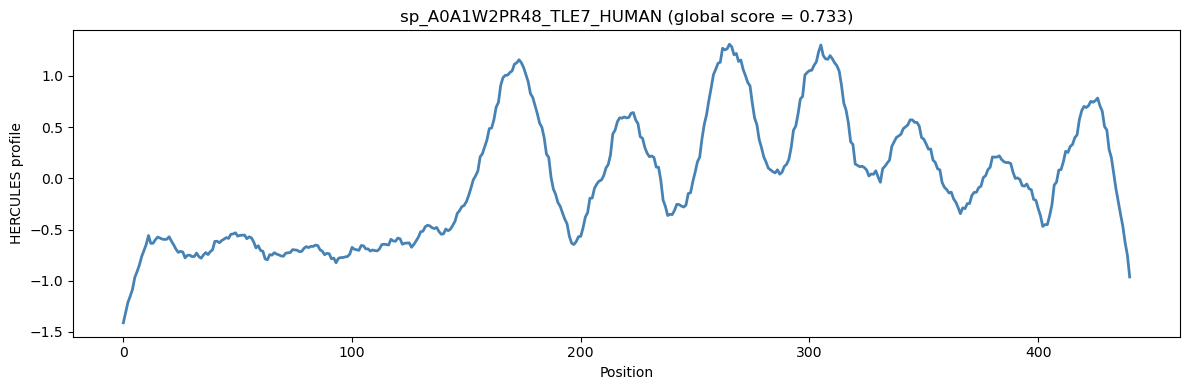

In [8]:
protein_id = "sp_A0A1W2PR48_TLE7_HUMAN"
profile_vals = df_profiles.loc[df_profiles["Protein"] == protein_id, "Profile"].values[0]
global_score = df_global.loc[df_global["Protein"] == protein_id, "HERCULES_global"].values[0]

plot_profile(profile_vals, protein_id=protein_id, global_score=global_score)

# 5️⃣ Perform mutagenesis scan for a single protein

In [9]:
protein_index = 0
sequence = sequences[protein_index]
protein_id = ids[protein_index]

df_mutagenesis = mutagenesis(
    sequence="MMKRRRRRAAA",
    n_jobs=-1,           # use all cores
    show_progress=True
)
print(df_mutagenesis.head())

Mutagenesis scanning: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:00<00:00, 12313.14it/s]


   position wt mutant  delta_score
0         1  M      A    -0.011934
1         1  M      C    -0.004074
2         1  M      D    -0.035487
3         1  M      E    -0.023034
4         1  M      F     0.008415


# 6️⃣ Plot mutagenesis heatmap

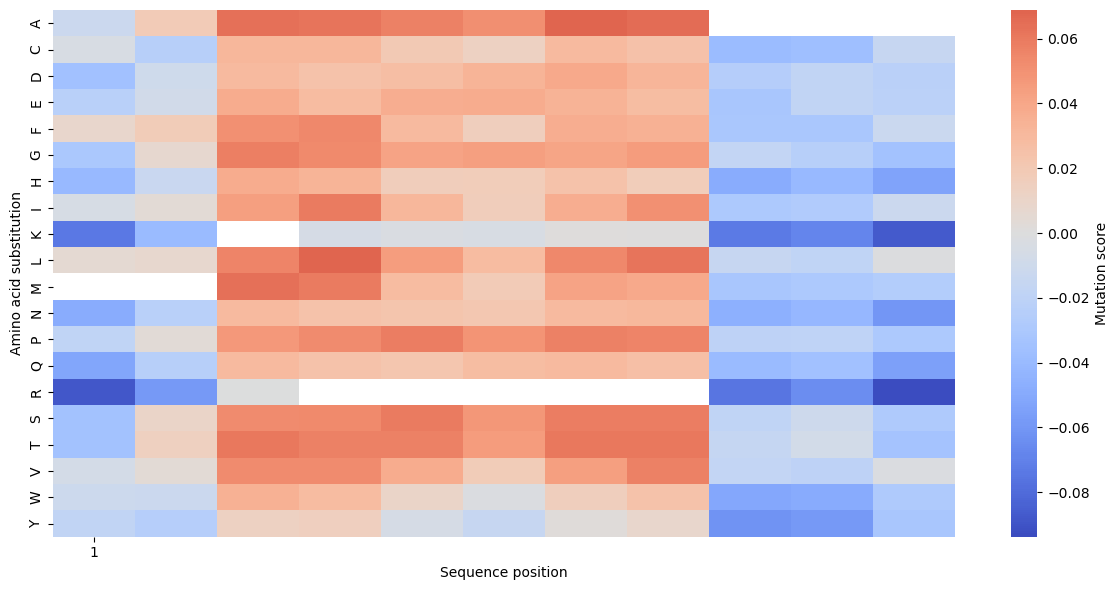

In [11]:
plot_mutagenesis_heatmap(df_mutagenesis)